In [3]:
pip install paho-mqtt

In [ ]:
import paho.mqtt.client as mqtt
import json

# Callback function for when a message is received
def on_message(client, userdata, msg):
    try:
        data = json.loads(msg.payload.decode())

        # Extract values with lowercase field names
        temperature = data.get("temperature", "N/A")
        humidity = data.get("humidity", "N/A")
        soil= data.get("soil", "N/A")
        print(f"Temperature: {temperature}°C, Humidity: {humidity}%")

    except json.JSONDecodeError:
        print("Received invalid JSON data")
        # MQTT setup
broker = "io.adafruit.com"
username = "braude1"   #insert Adafruit user name
aio_key = "" #insert key from Adafruit
topic = f"{username}/feeds/json"
client = mqtt.Client()
client.username_pw_set(username,aio_key)
client.on_message = on_message

client.connect(broker, 1883, 60)
client.subscribe(topic)

print(f"Subscribed to MQTT topic: {topic}")
client.loop_start()



Subscribed to MQTT topic: braude1/feeds/json


/tmp/ipykernel_433/2859147403.py:22: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


<MQTTErrorCode.MQTT_ERR_SUCCESS: 0>

In [ ]:
import requests

USERNAME = "braude1"   #insert Adafruit user name
# AIO_KEY = "" #insert key from Adafruit
FEED = "json"

url = f"https://io.adafruit.com/api/v2/{USERNAME}/feeds/{FEED}/data"
headers = {"X-AIO-Key": AIO_KEY}

response = requests.get(url, headers=headers)
data = response.json()

for item in data[:50]:  # חמשת הנתונים האחרונים
    print(f"Value: {item['value']}, Time: {item['created_at']}")


Value: {"temperature": 24.00, "humidity": 43.00, "tempThreshold": 43.00, "humThreshold": 95.00}, Time: 2026-05-11T08:41:20Z
Value: {"temperature": 24.00, "humidity": 43.00, "tempThreshold": 43.00, "humThreshold": 95.00}, Time: 2026-05-11T08:41:09Z
Value: {"temperature": 24.00, "humidity": 43.00, "tempThreshold": 43.00, "humThreshold": 95.00}, Time: 2026-05-11T08:41:00Z
Value: {"temperature": 24.00, "humidity": 44.00, "tempThreshold": 43.00, "humThreshold": 95.00}, Time: 2026-05-11T08:40:50Z
Value: {"temperature": 24.00, "humidity": 43.00, "tempThreshold": 43.00, "humThreshold": 95.00}, Time: 2026-05-11T08:40:40Z
Value: {"temperature": 24.00, "humidity": 44.00, "tempThreshold": 43.00, "humThreshold": 95.00}, Time: 2026-05-11T08:40:30Z
Value: {"temperature": 24.00, "humidity": 44.00, "tempThreshold": 43.00, "humThreshold": 95.00}, Time: 2026-05-11T08:40:20Z
Value: {"temperature": 24.00, "humidity": 44.00, "tempThreshold": 43.00, "humThreshold": 95.00}, Time: 2026-05-11T08:40:10Z
Value: {

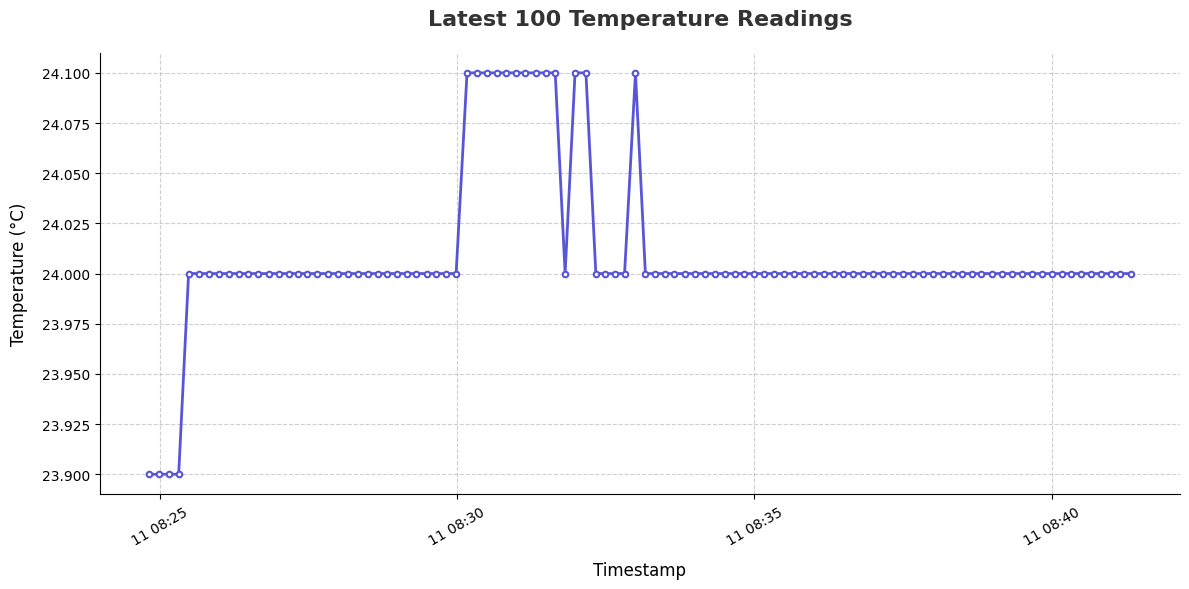

In [7]:
import matplotlib.pyplot as plt
import json
import pandas as pd

# Extracting data
values = []
timestamps = []

# Parse the last 100 items (or as many as available)
for item in data[:100]:
    try:
        # Assuming the 'value' field contains the JSON string with 'temperature'
        payload = json.loads(item['value'])
        val = payload.get('temperature')
        if val is not None:
            values.append(float(val))
            # Convert to datetime for better formatting
            timestamps.append(pd.to_datetime(item['created_at']))
    except (json.JSONDecodeError, ValueError, KeyError):
        continue

# Plotting with a sleek look
plt.style.use('seaborn-v0_8-muted') # Modern style
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# Reverse to show chronological order
ax.plot(timestamps[::-1], values[::-1], color='#5856d6', linewidth=2, marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1.5)

# Styling
ax.set_title('Latest 100 Temperature Readings', fontsize=16, fontweight='bold', pad=20, color='#333333')
ax.set_xlabel('Timestamp', fontsize=12, labelpad=10)
ax.set_ylabel('Temperature (°C)', fontsize=12, labelpad=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()